In [1]:
import sys
import wfdb
import neurokit2 as nk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("WFDB:", wfdb.__version__)
print("NeuroKit2:", nk.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

ModuleNotFoundError: No module named 'wfdb'

In [2]:
import sys
print(sys.executable)

C:\Users\othma\AppData\Local\Programs\Python\Python313\python.exe


In [3]:
C:\Users\othma\HF-Watch-AI\.venv\Scripts\python.exe -m pip install ipykernel

SyntaxError: unexpected character after line continuation character (2849534593.py, line 1)

In [4]:
C:\Users\othma\HF-Watch-AI\.venv\Scripts\python.exe -m pip install ipykernel

SyntaxError: unexpected character after line continuation character (2849534593.py, line 1)

In [5]:
C:\Users\othma\HF-Watch-AI\.venv\Scripts\python.exe -m ipykernel install --user --name hf-watch-ai --display-name "Python (HF-Watch-AI)"

SyntaxError: unexpected character after line continuation character (3758335097.py, line 1)

In [6]:
!C:\Users\othma\HF-Watch-AI\hf_env\Scripts\python.exe -m pip install ipykernel

In [7]:
!C:\Users\othma\HF-Watch-AI\hf_env\Scripts\python.exe -m ipykernel install --user --name hf-watch-ai --display-name "Python (HF-Watch-AI)"

Installed kernelspec hf-watch-ai in C:\Users\othma\AppData\Roaming\jupyter\kernels\hf-watch-ai


In [8]:
import os
print(os.listdir())

['.ipynb_checkpoints', '01_read_ecg.ipynb']


In [1]:
import sys
print(sys.executable)

C:\Users\othma\HF-Watch-AI\hf_env\Scripts\python.exe


In [2]:
import wfdb
import neurokit2 as nk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("✅ Everything works!")

✅ Everything works!


In [3]:
from pathlib import Path

DATA_DIR = Path.cwd().parent / "data" / "chfdb" / "files"

print("Dataset path:", DATA_DIR)
print("Folder exists:", DATA_DIR.exists())
print(list(DATA_DIR.glob("chf01.*")))

Dataset path: C:\Users\othma\HF-Watch-AI\data\chfdb\files
Folder exists: True
[WindowsPath('C:/Users/othma/HF-Watch-AI/data/chfdb/files/chf01.dat'), WindowsPath('C:/Users/othma/HF-Watch-AI/data/chfdb/files/chf01.ecg'), WindowsPath('C:/Users/othma/HF-Watch-AI/data/chfdb/files/chf01.hea'), WindowsPath('C:/Users/othma/HF-Watch-AI/data/chfdb/files/chf01.hea-')]


In [4]:
import wfdb

record_path = DATA_DIR / "chf01"
record = wfdb.rdrecord(str(record_path))

print("Sampling frequency:", record.fs)
print("Signal names:", record.sig_name)
print("Signal shape:", record.p_signal.shape)

Sampling frequency: 250
Signal names: ['ECG1', 'ECG2']
Signal shape: (17994491, 2)


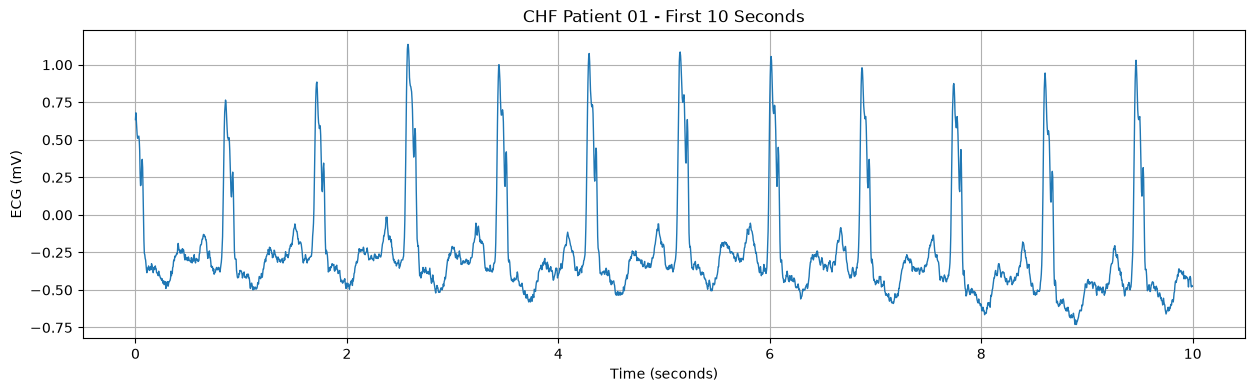

In [5]:
# Take the first ECG channel
ecg = record.p_signal[:, 0]

# Plot only the first 10 seconds
seconds = 10
samples = int(record.fs * seconds)

time = np.arange(samples) / record.fs

plt.figure(figsize=(15,4))
plt.plot(time, ecg[:samples], linewidth=1)

plt.title("CHF Patient 01 - First 10 Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("ECG (mV)")
plt.grid(True)

plt.show()

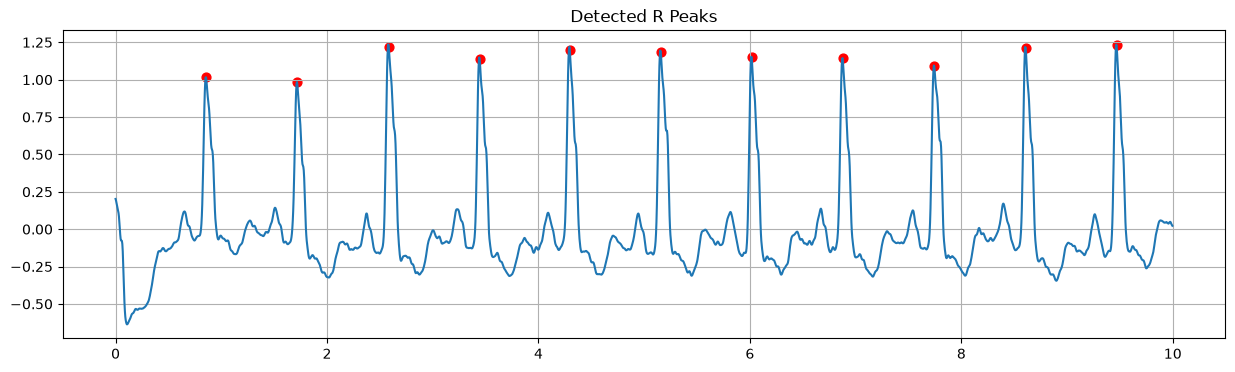

In [6]:
cleaned = nk.ecg_clean(ecg[:samples], sampling_rate=record.fs)

signals, info = nk.ecg_process(
    cleaned,
    sampling_rate=record.fs
)

rpeaks = info["ECG_R_Peaks"]

plt.figure(figsize=(15,4))
plt.plot(time, cleaned)

plt.scatter(
    rpeaks/record.fs,
    cleaned[rpeaks],
    color="red",
    s=40
)

plt.title("Detected R Peaks")
plt.grid(True)
plt.show()

In [8]:
# =====================================================
# STEP 4 - Extract HRV Features
# =====================================================


In [9]:
hrv = nk.hrv(info, sampling_rate=record.fs)

print(hrv.T)

                                      0
HRV_MeanNN                   861.200000
HRV_SDNN                       4.638007
HRV_SDANN1                          NaN
HRV_SDNNI1                          NaN
HRV_SDANN2                          NaN
...                                 ...
HRV_LZC                        1.660964
HRV_Symbolic_EqualProb4_0V     0.125000
HRV_Symbolic_EqualProb4_1V     0.500000
HRV_Symbolic_EqualProb4_2LV    0.125000
HRV_Symbolic_EqualProb4_2UV    0.250000

[79 rows x 1 columns]


C:\Users\othma\HF-Watch-AI\hf_env\Lib\site-packages\neurokit2\complexity\entropy_multiscale.py:346: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapezoid(mse) / len(mse)
C:\Users\othma\HF-Watch-AI\hf_env\Lib\site-packages\neurokit2\complexity\optim_complexity_k.py:134: RuntimeWarning: divide by zero encountered in divide
  normalization = (n - 1) / (np.floor((n - k_subrange) / k).astype(int) * k)
C:\Users\othma\HF-Watch-AI\hf_env\Lib\site-packages\neurokit2\complexity\optim_complexity_k.py:135: RuntimeWarning: invalid value encountered in multiply
  sets = (np.nansum(np.abs(np.diff(sig_values)), axis=1) * normalization) / k


In [10]:
# Use the first 5 minutes of ECG
seconds = 300
samples = int(record.fs * seconds)

ecg_5min = record.p_signal[:samples, 0]

# Clean ECG and detect R-peaks
cleaned_5min = nk.ecg_clean(
    ecg_5min,
    sampling_rate=record.fs
)

signals_5min, info_5min = nk.ecg_process(
    cleaned_5min,
    sampling_rate=record.fs
)

print("Detected beats:", len(info_5min["ECG_R_Peaks"]))

Detected beats: 332


In [11]:
hrv_5min = nk.hrv(
    info_5min,
    sampling_rate=record.fs,
    show=False
)

hrv_5min.T

,0
HRV_MeanNN,902.078550
HRV_SDNN,31.419448
HRV_SDANN1,25.039066
HRV_SDNNI1,20.148328
HRV_SDANN2,NaN
...,...
HRV_LZC,0.455204
HRV_Symbolic_EqualProb4_0V,0.544073
HRV_Symbolic_EqualProb4_1V,0.334347
HRV_Symbolic_EqualProb4_2LV,0.015198


In [12]:
print("Total features:", hrv_5min.shape[1])
print("Missing features:", hrv_5min.isna().sum().sum())

Total features: 95
Missing features: 5


In [13]:
hrv_5min.to_csv(
    "../results/chf01_hrv_5min.csv",
    index=False
)

print("Saved successfully.")

Saved successfully.


In [14]:
from pathlib import Path
import pandas as pd
import neurokit2 as nk
import wfdb

DATA_DIR = Path.cwd().parent / "data" / "chfdb" / "files"
RESULTS_DIR = Path.cwd().parent / "results"
RESULTS_DIR.mkdir(exist_ok=True)

all_features = []

for patient_number in range(1, 16):
    patient_id = f"chf{patient_number:02d}"
    record_path = DATA_DIR / patient_id

    print("Processing:", patient_id)

    try:
        record = wfdb.rdrecord(str(record_path))

        sampling_rate = record.fs
        samples_5min = int(sampling_rate * 300)

        ecg = record.p_signal[:samples_5min, 0]

        cleaned = nk.ecg_clean(
            ecg,
            sampling_rate=sampling_rate
        )

        signals, info = nk.ecg_process(
            cleaned,
            sampling_rate=sampling_rate
        )

        hrv = nk.hrv(
            info,
            sampling_rate=sampling_rate,
            show=False
        )

        hrv.insert(0, "patient_id", patient_id)
        hrv.insert(1, "label", 1)

        all_features.append(hrv)

    except Exception as error:
        print(f"Error in {patient_id}: {error}")

chf_features = pd.concat(all_features, ignore_index=True)

output_path = RESULTS_DIR / "chf_all_patients_5min.csv"
chf_features.to_csv(output_path, index=False)

print("Finished.")
print("Shape:", chf_features.shape)
print("Saved to:", output_path)

chf_features.head()

Processing: chf01
Processing: chf02
Processing: chf03
Processing: chf04
Processing: chf05
Processing: chf06
Processing: chf07
Processing: chf08
Processing: chf09
Processing: chf10
Processing: chf11
Processing: chf12
Processing: chf13
Processing: chf14
Processing: chf15
Finished.
Shape: (15, 97)
Saved to: C:\Users\othma\HF-Watch-AI\results\chf_all_patients_5min.csv


,patient_id,label,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,...,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC,HRV_Symbolic_EqualProb4_0V,HRV_Symbolic_EqualProb4_1V,HRV_Symbolic_EqualProb4_2LV,HRV_Symbolic_EqualProb4_2UV
0,chf01,1,902.078550,31.419448,25.039066,20.148328,NaN,NaN,NaN,NaN,...,0.941250,1.432660,1.699604,1.649131,2.139107,0.455204,0.544073,0.334347,0.015198,0.106383
1,chf02,1,614.431211,23.603090,14.213242,19.480844,NaN,NaN,NaN,NaN,...,1.306102,1.748969,1.450535,1.715999,2.529219,0.586630,0.521649,0.342268,0.020619,0.115464
2,chf03,1,1318.590308,729.801224,112.302974,727.280619,NaN,NaN,NaN,NaN,...,0.668893,0.536292,0.240399,1.892232,2.379361,0.896433,0.337778,0.417778,0.057778,0.186667
3,chf04,1,627.555556,17.446303,12.415484,12.937957,NaN,NaN,NaN,NaN,...,1.289304,2.315296,1.656360,1.889935,2.574745,0.690189,0.334737,0.456842,0.048421,0.160000
4,chf05,1,551.033210,29.696848,13.906130,21.702661,NaN,NaN,NaN,NaN,...,1.033859,1.492808,1.066852,1.549435,1.899450,0.402162,0.631481,0.290741,0.003704,0.074074
